# 🎵 Clasificación de Géneros Musicales con Deep Learning
## Arquitectura: CNN + Transformer (Audio Spectrogram Transformer adaptado)

### Justificación de la arquitectura elegida

Para clasificación de audio, el pipeline más efectivo actualmente combina:
1. **Extracción de features con Mel-Spectrograma**: Convierte el audio (señal 1D) en una imagen 2D que captura frecuencia y tiempo simultáneamente. Es la representación estándar en audio deep learning.
2. **CNN frontend (EfficientNet/ResNet ligero)**: Extrae features locales del espectrograma (patrones rítmicos, tímbricos, frecuenciales).
3. **Transformer encoder**: Captura dependencias de largo alcance en la secuencia temporal, crucial para distinguir géneros con estructuras rítmicas similares.

**¿Por qué NO usar solo LSTM/RNN?**
- Las RNN/LSTM procesan secuencialmente → más lentas y con problemas de gradiente en clips de 20s
- Los Transformers capturan relaciones globales en una sola pasada (self-attention)
- En benchmarks de audio (GTZAN, AudioSet), CNN+Transformer supera consistentemente a arquitecturas RNN

**¿Por qué NO usar solo CNN?**
- Las CNN son locales por naturaleza: capturan bien texturas y patrones cortos
- Para géneros musicales, la estructura temporal de largo plazo es discriminativa (ej: salsa vs reggaeton vs rock)
- El Transformer complementa capturando esas relaciones globales

### Estrategias anti-overfitting implementadas
- **Dropout** en múltiples capas
- **SpecAugment**: Data augmentation directamente sobre el espectrograma (máscaras de tiempo y frecuencia)
- **Audio Augmentation**: Pitch shift, time stretch, ruido gaussiano
- **Label Smoothing**: Suaviza las etiquetas duras para mejorar calibración
- **Class-weighted loss**: Maneja el severo desbalance de clases (clase 12 tiene 94x más muestras que clase 14)
- **Early stopping + ReduceLROnPlateau**
- **Mixup augmentation** (opcional, implementado)
- **Weight decay (AdamW)**

## 1. Instalación de dependencias

In [7]:
# Instalamos librerías necesarias para procesamiento de audio
# librosa: extracción de features de audio (MFCC, Mel-spectrograma, etc.)
# audiomentations: data augmentation de audio de alta calidad
# timm: librería de modelos de visión pre-entrenados (usaremos EfficientNet como backbone CNN)

!pip install librosa audiomentations timm

In [8]:
pip show librosa audiomentations timm

Name: librosa
Version: 0.11.0
Summary: Python module for audio and music processing
Home-page: https://librosa.org
Author: Brian McFee, librosa development team
Author-email: brian.mcfee@nyu.edu
License: ISC
Location: /usr/local/lib/python3.12/dist-packages
Requires: audioread, decorator, joblib, lazy_loader, msgpack, numba, numpy, pooch, scikit-learn, scipy, soundfile, soxr, typing_extensions
Required-by: audiomentations
---
Name: audiomentations
Version: 0.43.1
Summary: A Python library for audio data augmentation. Inspired by albumentations. Useful for machine learning.
Home-page: https://github.com/iver56/audiomentations
Author: Iver Jordal
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: librosa, numpy, numpy-minmax, numpy-rms, python-stretch, scipy, soxr
Required-by: 
---
Name: timm
Version: 1.0.25
Summary: PyTorch Image Models
Home-page: https://github.com/huggingface/pytorch-image-models
Author: 
Author-email: Ross Wightman <ross@huggingfa

## 2. Imports y configuración global

In [9]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

# Audio
import librosa
import librosa.display
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast  # Mixed precision

# Vision backbone
import timm

# Métricas
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

# =====================================================================
# CONFIGURACIÓN GLOBAL
# =====================================================================
# Centralizamos todos los hiperparámetros aquí para facilitar ablaciones

CFG = {
    # Paths
    'path': '/kaggle/input/datasets/jeffreyamc/music-genres-lab/',
    
    # Audio preprocessing
    'sample_rate': 22050,      # Sample rate estándar para música
    'duration': 20,            # Clips de ~20 segundos según el enunciado
    'n_mels': 128,             # Número de bandas Mel: balance entre resolución y costo computacional
    'n_fft': 2048,             # Tamaño de ventana FFT: captura ~93ms a 22050Hz
    'hop_length': 512,         # Solapamiento de ventanas: define resolución temporal
    'fmin': 20,                # Frecuencia mínima (Hz) - límite audición humana
    'fmax': 8000,              # Frecuencia máxima - suficiente para música
    
    # Espectrograma resultante: (128, ~862) para clips de 20s
    # Lo redimensionamos a tamaño fijo para el CNN
    'img_size': (128, 512),    # (n_mels, timesteps) - input al modelo
    
    # Modelo
    'backbone': 'tf_efficientnet_b2_ns',  # EfficientNet B2 con Noisy Student pretraining
    'n_classes': 15,
    'dropout': 0.3,
    
    # Transformer dentro del modelo
    'transformer_dim': 512,
    'transformer_heads': 8,
    'transformer_layers': 4,
    
    # Entrenamiento
    'epochs': 50,
    'batch_size': 32,
    'lr': 1e-4,
    'weight_decay': 1e-4,      # L2 regularización vía AdamW
    'label_smoothing': 0.1,    # Evita que el modelo sea demasiado confiante
    'mixup_alpha': 0.4,        # Parámetro de Mixup augmentation
    'use_mixup': True,
    
    # SpecAugment
    'freq_mask_param': 30,     # Máximo de bandas de frecuencia a enmascarar
    'time_mask_param': 80,     # Máximo de timesteps a enmascarar
    'num_freq_masks': 2,
    'num_time_masks': 2,
    
    # Cross-validation
    'n_folds': 5,
    'fold': 0,                 # Fold a entrenar (cambiar para ensemble)
    
    # Hardware
    'seed': 42,
    'num_workers': 4,
    'pin_memory': True,
    'fp16': True,              # Mixed precision para acelerar entrenamiento en GPU
}

# Reproducibilidad
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Usando dispositivo: cuda
GPU: Tesla T4
VRAM disponible: 15.6 GB


## 3. Carga y exploración de datos

In [11]:
path = CFG['path']
files = os.listdir(path)
print(f'Total de archivos/carpetas: {len(files)}')
print(files)

# Cargamos los CSVs de labels
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
#test_df = pd.read_csv(os.path.join(path, 'test.csv'))

print(f'\nTrain shape: {train_df.shape}')
train_df.head()

Total de archivos/carpetas: 3
['train.csv', 'test', 'train']

Train shape: (18719, 2)


,Id,Target
0,36c2908477b59e0c,3
1,1bfb76e7780b79e1,6
2,0c1b089e840e1175,7
3,c1058d8c21cbf37d,4
4,469ccd3c914a7965,3


Distribución de clases:
Target
0       56
1      464
2      134
3     4733
4     1687
5     1138
6     1644
7     1012
8      763
9      288
10     383
11     889
12    5323
13     116
14      89
Name: count, dtype: int64


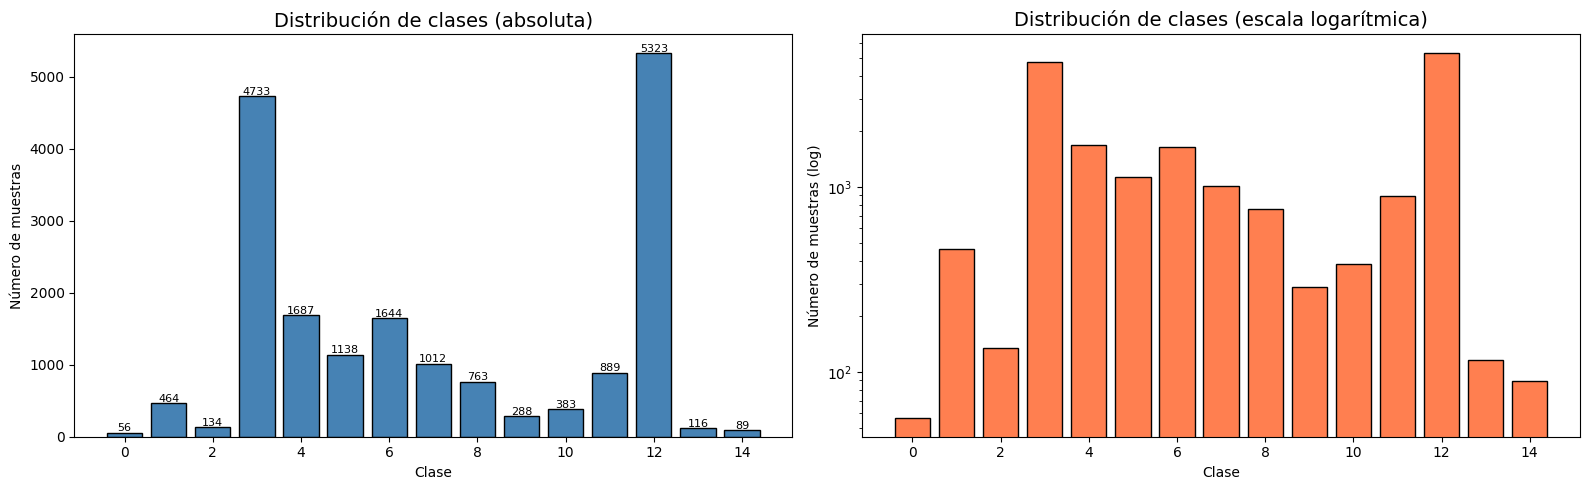


Clase más frecuente: 12 (5323 muestras)
Clase menos frecuente: 0 (56 muestras)
Ratio de desbalance: 95.1x


In [12]:
# =====================================================================
# ANÁLISIS DEL DESBALANCE DE CLASES
# =====================================================================
# El desbalance es SEVERO: clase 12 (5323) vs clase 14 (89) → ratio 60:1
# Esto afecta directamente el Macro F1 porque las clases minoritarias
# tienen el mismo peso que las mayoritarias en la métrica final.

class_dist = train_df['Target'].value_counts().sort_index()
print('Distribución de clases:')
print(class_dist)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución absoluta
axes[0].bar(class_dist.index, class_dist.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de clases (absoluta)', fontsize=14)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(class_dist.values):
    axes[0].text(class_dist.index[i], v + 20, str(v), ha='center', fontsize=8)

# Distribución log-scale para ver mejor las clases minoritarias
axes[1].bar(class_dist.index, class_dist.values, color='coral', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de clases (escala logarítmica)', fontsize=14)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Número de muestras (log)')

plt.tight_layout()
plt.show()

print(f'\nClase más frecuente: {class_dist.idxmax()} ({class_dist.max()} muestras)')
print(f'Clase menos frecuente: {class_dist.idxmin()} ({class_dist.min()} muestras)')
print(f'Ratio de desbalance: {class_dist.max() / class_dist.min():.1f}x')

Archivos train existentes: 18719/18719
Archivos test existentes:  6240/6240


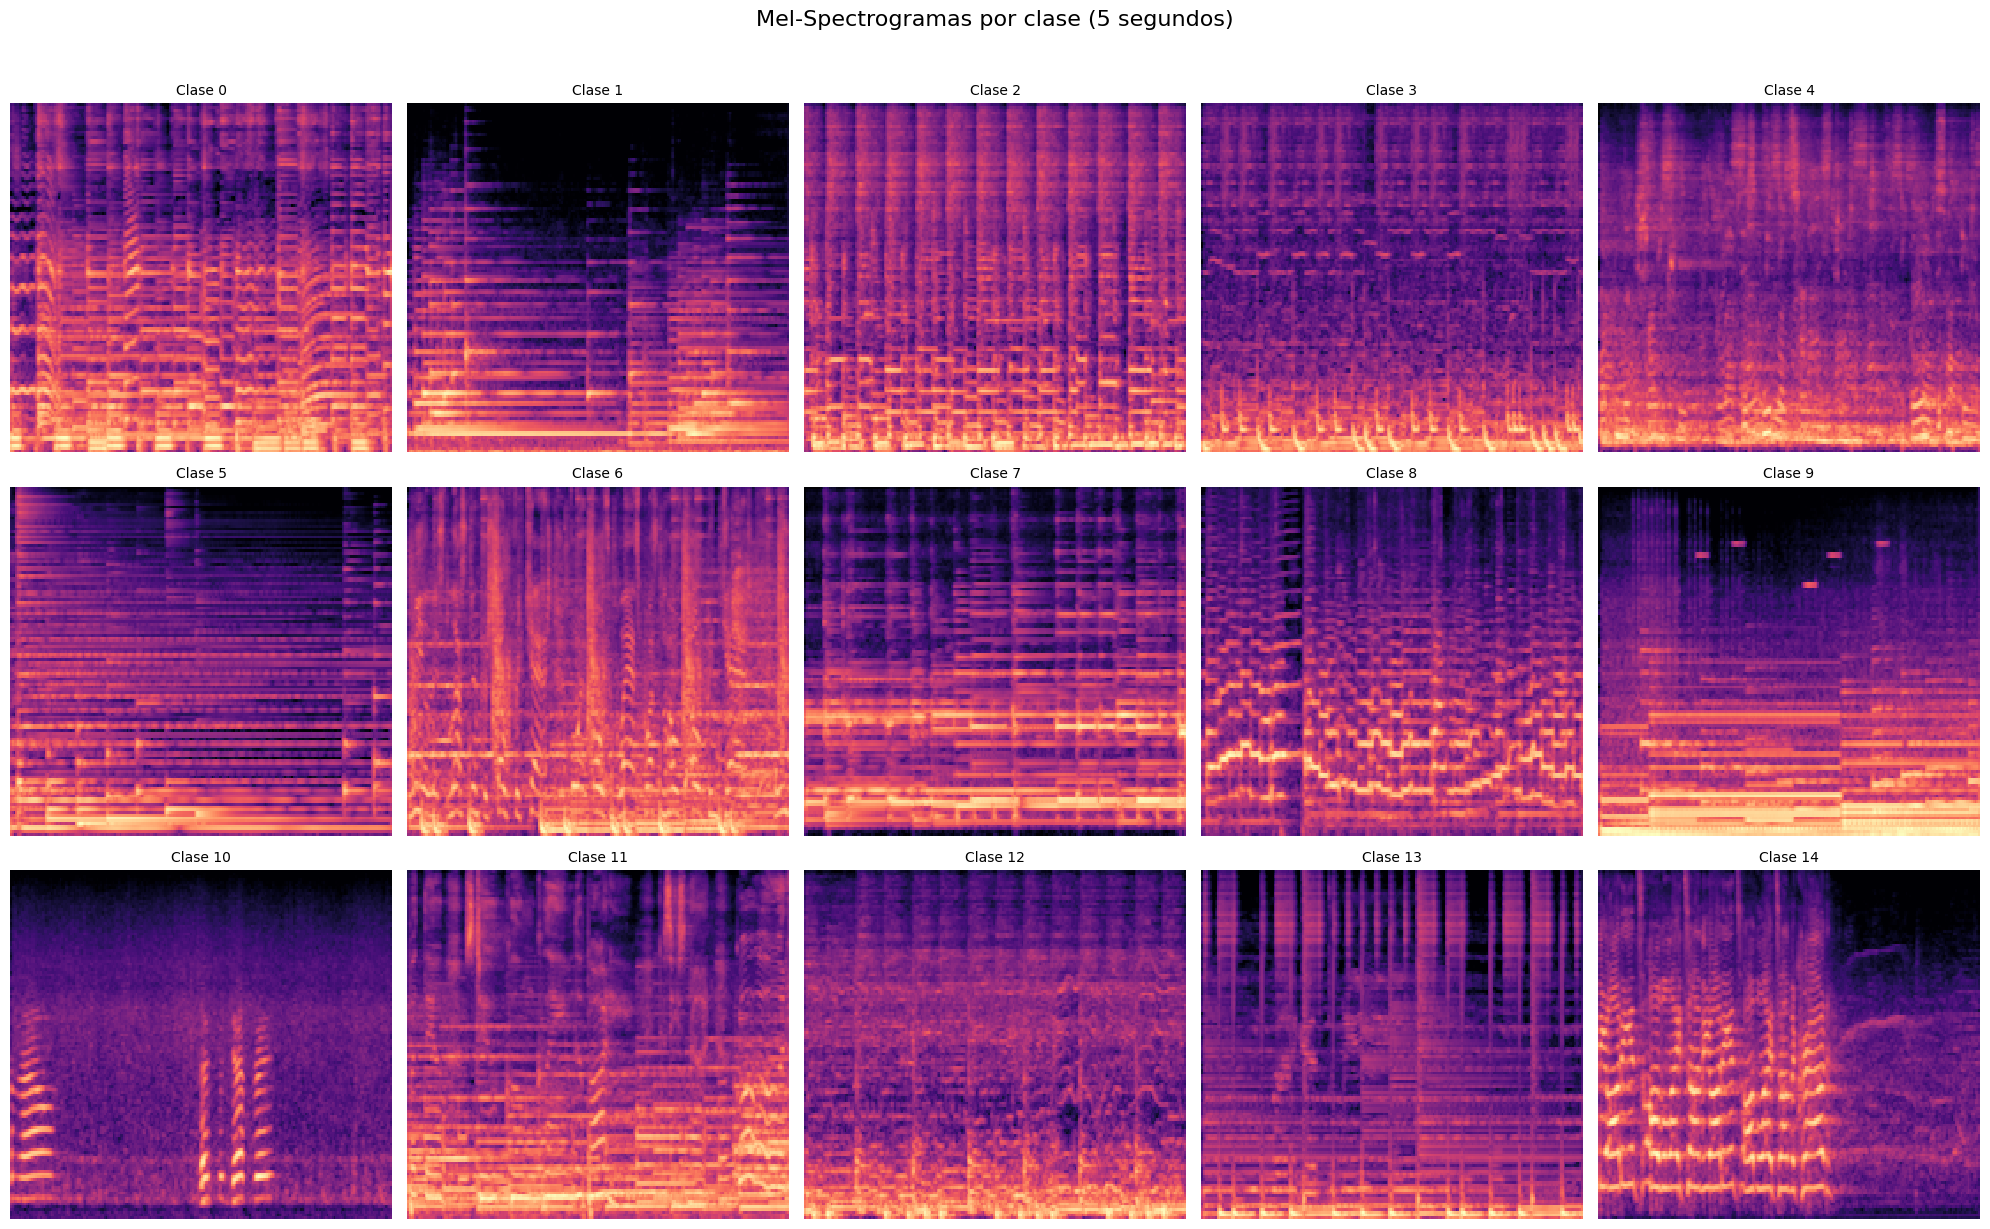

In [23]:
# Verificamos rutas de audio y ejemplos
train_audio_path = os.path.join(path, 'train/train')
test_audio_path  = os.path.join(path, 'test/test')

# Construimos columna con ruta completa
train_df['filepath'] = train_df['Id'].apply(lambda x: os.path.join(train_audio_path, f'{x}.wav'))

test_files = [f.replace('.wav', '') for f in os.listdir(test_audio_path) if f.endswith('.wav')]
test_df = pd.DataFrame({'Id': test_files})
test_df['filepath'] = test_df['Id'].apply(lambda x: os.path.join(test_audio_path, f'{x}.wav'))

# Verificamos que los archivos existen
print(f'Archivos train existentes: {train_df["filepath"].apply(os.path.exists).sum()}/{len(train_df)}')
print(f'Archivos test existentes:  {test_df["filepath"].apply(os.path.exists).sum()}/{len(test_df)}')

# Visualizamos un ejemplo de espectrograma por clase
sample_paths = train_df.groupby('Target').first()['filepath']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, (cls, fp) in enumerate(sample_paths.items()):
    try:
        y, sr = librosa.load(fp, sr=CFG['sample_rate'], duration=5)  # Solo 5s para visualización
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=CFG['n_mels'],
            n_fft=CFG['n_fft'], hop_length=CFG['hop_length']
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, ax=axes[idx], sr=sr, hop_length=CFG['hop_length'])
        axes[idx].set_title(f'Clase {cls}', fontsize=10)
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].set_title(f'Clase {cls} - Error', fontsize=10)

plt.suptitle('Mel-Spectrogramas por clase (5 segundos)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento de Audio y Dataset

### ¿Por qué Mel-Spectrograma?
- La escala Mel imita la percepción humana del sonido (logarítmica en frecuencia)
- Convierte audio 1D → imagen 2D tratando el problema como clasificación de imágenes
- Es el input estándar en sistemas de reconocimiento de audio (ASR, Music IR)
- Permite aprovechar backbones CNN pre-entrenados en ImageNet

Funciones de preprocesamiento definidas ✓
Shape del Mel-Spectrograma: (128, 512)


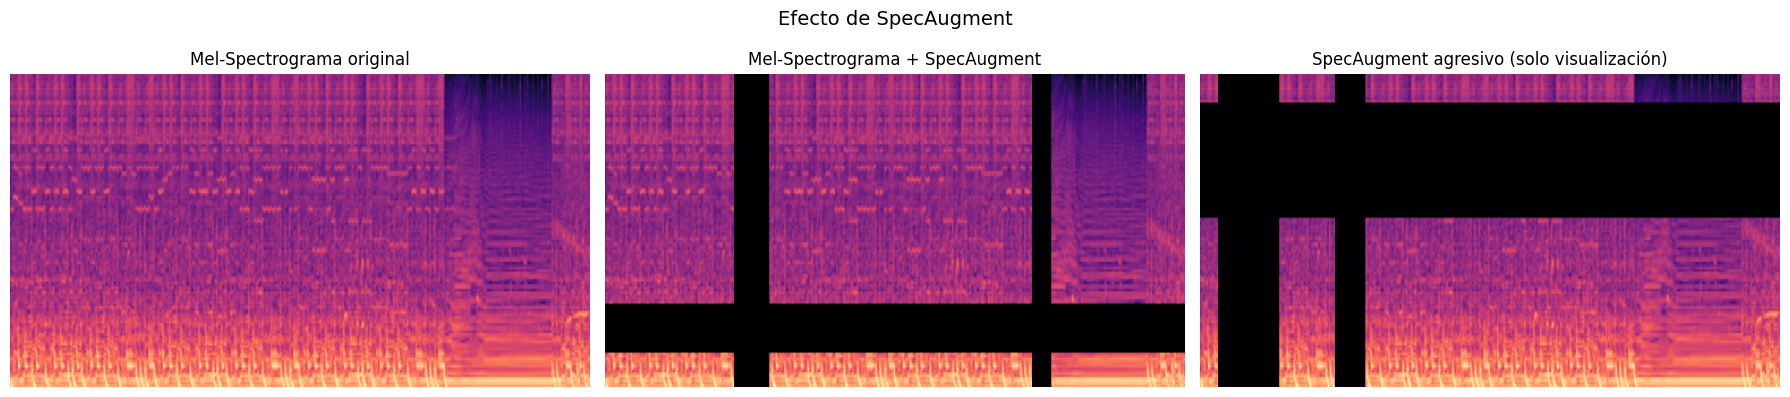

In [16]:
# =====================================================================
# DATA AUGMENTATION DE AUDIO
# =====================================================================
# Aplicamos augmentation SOLO al set de entrenamiento.
# Estas transformaciones preservan la semántica del género musical:
# - Ruido gaussiano: simula grabaciones de baja calidad
# - TimeStretch: cambia tempo sin alterar pitch (preserva género)
# - PitchShift: cambia tonalidad (el género sigue siendo el mismo)
# - Shift: desplaza el audio en el tiempo

audio_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.3),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
    Shift(min_shift=-0.1, max_shift=0.1, p=0.2),
])


def load_audio(filepath, sr=22050, duration=20):
    """Carga audio con manejo de errores y padding/truncado."""
    try:
        y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)
    except Exception:
        # Si falla la carga, retornamos silencio
        y = np.zeros(sr * duration, dtype=np.float32)
    
    # Padding si el clip es más corto que duration
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='reflect')
    else:
        y = y[:target_len]
    
    return y.astype(np.float32)


def audio_to_melspec(y, sr=22050, n_mels=128, n_fft=2048, hop_length=512,
                     fmin=20, fmax=8000, img_size=(128, 512)):
    """
    Convierte señal de audio a Mel-Spectrograma normalizado.
    
    Pasos:
    1. STFT (Short-Time Fourier Transform)
    2. Proyección a escala Mel
    3. Conversión a dB (log-compresión)
    4. Normalización [0, 1]
    5. Resize al tamaño fijo del modelo
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_length, fmin=fmin, fmax=fmax
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Normalización a [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    
    # Resize al tamaño objetivo
    from PIL import Image
    mel_img = Image.fromarray((mel_db * 255).astype(np.uint8))
    mel_img = mel_img.resize((img_size[1], img_size[0]))
    mel_np = np.array(mel_img) / 255.0
    
    return mel_np.astype(np.float32)


def spec_augment(mel, freq_mask_param=30, time_mask_param=80,
                 num_freq_masks=2, num_time_masks=2):
    """
    SpecAugment (Park et al., 2019) - Augmentation SOBRE el espectrograma.
    
    Aplica máscaras aleatorias en:
    - Frecuencia: simula que algunas frecuencias no son audibles/grabadas
    - Tiempo: simula dropout temporal, obliga al modelo a no depender
              de momentos específicos del clip
    
    Demostrado efectivo en ASR (Google) y transferido con éxito a
    clasificación de audio en general.
    """
    mel = mel.copy()
    freq_size, time_size = mel.shape
    
    # Máscaras de frecuencia
    for _ in range(num_freq_masks):
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, freq_size - f)
        mel[f0:f0 + f, :] = 0.0
    
    # Máscaras de tiempo
    for _ in range(num_time_masks):
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, time_size - t)
        mel[:, t0:t0 + t] = 0.0
    
    return mel


print('Funciones de preprocesamiento definidas ✓')

# Test rápido con un archivo
sample_file = train_df['filepath'].iloc[0]
y = load_audio(sample_file, sr=CFG['sample_rate'], duration=CFG['duration'])
mel = audio_to_melspec(y, **{
    'sr': CFG['sample_rate'],
    'n_mels': CFG['n_mels'],
    'n_fft': CFG['n_fft'],
    'hop_length': CFG['hop_length'],
    'fmin': CFG['fmin'],
    'fmax': CFG['fmax'],
    'img_size': CFG['img_size']
})
print(f'Shape del Mel-Spectrograma: {mel.shape}')  # Debe ser (128, 512)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(mel, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('Mel-Spectrograma original')

mel_aug = spec_augment(mel, CFG['freq_mask_param'], CFG['time_mask_param'])
axes[1].imshow(mel_aug, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Mel-Spectrograma + SpecAugment')

# SpecAugment más agresivo para visualizar
mel_aug2 = spec_augment(mel, 50, 120, 3, 3)
axes[2].imshow(mel_aug2, aspect='auto', origin='lower', cmap='magma')
axes[2].set_title('SpecAugment agresivo (solo visualización)')

for ax in axes:
    ax.axis('off')
plt.suptitle('Efecto de SpecAugment', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# =====================================================================
# DATASET CLASS
# =====================================================================

class MusicGenreDataset(Dataset):
    """
    Dataset para clasificación de géneros musicales.
    
    Pipeline:
    1. Carga audio .wav
    2. Aplica audio augmentation (solo train)
    3. Convierte a Mel-Spectrograma
    4. Aplica SpecAugment (solo train)
    5. Convierte a tensor 3 canales (repite el canal para usar CNN pre-entrenado en RGB)
    
    Nota sobre 3 canales:
    Los backbones CNN están pre-entrenados en ImageNet (RGB).
    Repetir el canal 3 veces permite usar esos pesos pre-entrenados,
    acelerando la convergencia significativamente.
    """
    
    def __init__(self, df, cfg, is_train=True):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.is_train = is_train
        self.has_labels = 'Target' in df.columns
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Cargar audio
        y = load_audio(row['filepath'], sr=self.cfg['sample_rate'], duration=self.cfg['duration'])
        
        # 2. Audio augmentation (solo entrenamiento)
        if self.is_train:
            y = audio_augmentations(y, sample_rate=self.cfg['sample_rate'])
        
        # 3. Convertir a Mel-Spectrograma
        mel = audio_to_melspec(
            y,
            sr=self.cfg['sample_rate'],
            n_mels=self.cfg['n_mels'],
            n_fft=self.cfg['n_fft'],
            hop_length=self.cfg['hop_length'],
            fmin=self.cfg['fmin'],
            fmax=self.cfg['fmax'],
            img_size=self.cfg['img_size']
        )
        
        # 4. SpecAugment (solo entrenamiento)
        if self.is_train:
            mel = spec_augment(
                mel,
                freq_mask_param=self.cfg['freq_mask_param'],
                time_mask_param=self.cfg['time_mask_param'],
                num_freq_masks=self.cfg['num_freq_masks'],
                num_time_masks=self.cfg['num_time_masks']
            )
        
        # 5. Convertir a tensor (3, H, W) para backbone CNN
        # Normalizamos con media y std de ImageNet para aprovechar pretraining
        mel_tensor = torch.tensor(mel).unsqueeze(0).repeat(3, 1, 1)  # (1, H, W) → (3, H, W)
        
        # Normalización ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        mel_tensor = (mel_tensor - mean) / std
        
        if self.has_labels:
            label = torch.tensor(row['Target'], dtype=torch.long)
            return mel_tensor, label
        else:
            return mel_tensor


# Test rápido del dataset
test_dataset = MusicGenreDataset(train_df.head(5), CFG, is_train=True)
x, y = test_dataset[0]
print(f'Shape del tensor de entrada: {x.shape}')   # (3, 128, 512)
print(f'Label: {y.item()}')
print(f'Min/Max del tensor: {x.min():.3f} / {x.max():.3f}')

Shape del tensor de entrada: torch.Size([3, 128, 512])
Label: 3
Min/Max del tensor: -2.118 / 1.751


## 5. Manejo del Desbalance de Clases

Usamos dos estrategias complementarias:
1. **WeightedRandomSampler**: Sobremuestra las clases minoritarias durante el entrenamiento
2. **Class-weighted CrossEntropyLoss**: Penaliza más los errores en clases raras

Pesos de clase (normalizados):
  Clase  0:    56 muestras → peso = 22.2845
  Clase  1:   464 muestras → peso = 2.6895
  Clase  2:   134 muestras → peso = 9.3129
  Clase  3:  4733 muestras → peso = 0.2637
  Clase  4:  1687 muestras → peso = 0.7397
  Clase  5:  1138 muestras → peso = 1.0966
  Clase  6:  1644 muestras → peso = 0.7591
  Clase  7:  1012 muestras → peso = 1.2331
  Clase  8:   763 muestras → peso = 1.6356
  Clase  9:   288 muestras → peso = 4.3331
  Clase 10:   383 muestras → peso = 3.2583
  Clase 11:   889 muestras → peso = 1.4037
  Clase 12:  5323 muestras → peso = 0.2344
  Clase 13:   116 muestras → peso = 10.7580
  Clase 14:    89 muestras → peso = 14.0217


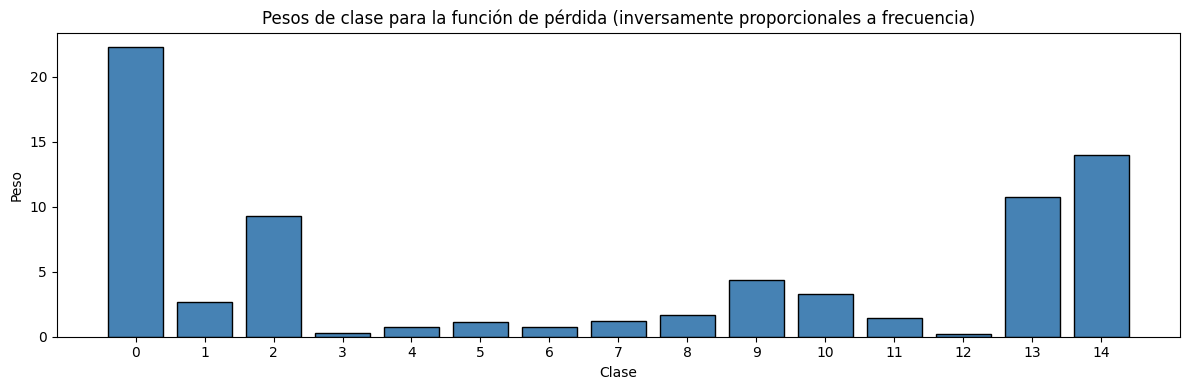

In [18]:
def get_class_weights(labels, n_classes=15):
    """
    Calcula pesos inversamente proporcionales a la frecuencia de clase.
    
    Fórmula: weight_c = N_total / (N_classes * N_c)
    Esto equilibra el gradiente: las clases raras reciben gradientes más grandes.
    """
    class_counts = np.bincount(labels, minlength=n_classes).astype(float)
    # Evitamos división por cero para clases sin muestras
    class_counts = np.where(class_counts == 0, 1, class_counts)
    weights = len(labels) / (n_classes * class_counts)
    return torch.FloatTensor(weights)


def get_sampler_weights(labels, class_weights):
    """
    Para WeightedRandomSampler: cada muestra recibe el peso de su clase.
    El sampler usa estos pesos para determinar la probabilidad de muestreo.
    """
    sample_weights = class_weights[labels]
    return sample_weights


# Calculamos pesos
train_labels = train_df['Target'].values
class_weights = get_class_weights(train_labels, CFG['n_classes'])

print('Pesos de clase (normalizados):')
for i, w in enumerate(class_weights):
    count = (train_labels == i).sum()
    print(f'  Clase {i:2d}: {count:5d} muestras → peso = {w:.4f}')

plt.figure(figsize=(12, 4))
plt.bar(range(CFG['n_classes']), class_weights.numpy(), color='steelblue', edgecolor='black')
plt.xlabel('Clase')
plt.ylabel('Peso')
plt.title('Pesos de clase para la función de pérdida (inversamente proporcionales a frecuencia)')
plt.xticks(range(CFG['n_classes']))
plt.tight_layout()
plt.show()

## 6. Arquitectura del Modelo: CNN + Transformer

### Diseño de la arquitectura

```
Input: Mel-Spectrograma (3, 128, 512)
         ↓
  EfficientNet-B2 (backbone CNN)
  → Extrae features espaciales locales
  → Output: feature map (C, H', W')
         ↓
  Flatten temporal: (C, H'*W') → secuencia de tokens
         ↓
  Positional Encoding
         ↓
  Transformer Encoder (4 capas, 8 heads)
  → Self-attention captura relaciones temporales globales
         ↓
  Global Average Pooling
         ↓
  Classification Head (MLP + Dropout)
         ↓
  Output: 15 clases
```

In [19]:
class PositionalEncoding(nn.Module):
    """
    Encoding posicional sinusoidal (Vaswani et al., 2017).
    
    Los Transformers no tienen noción inherente del orden de la secuencia
    (a diferencia de RNN/LSTM). El PE inyecta información de posición
    usando funciones sinusoidales: cada posición tiene un vector único.
    
    ¿Por qué sinusoidal y no learnable?
    - Funciona para secuencias más largas que las vistas en training
    - Menos parámetros
    - Demostrado igual de efectivo en la práctica
    """
    def __init__(self, d_model, max_len=2000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class AudioCNNTransformer(nn.Module):
    """
    Modelo híbrido CNN + Transformer para clasificación de audio.
    
    Componentes:
    1. CNN Backbone (EfficientNet-B2):
       - Pre-entrenado en ImageNet
       - Extrae representaciones de bajo y alto nivel del espectrograma
       - Usamos los features del penúltimo layer (antes de clasificación)
    
    2. Proyección de dimensión:
       - Adapta los features del CNN al tamaño esperado por el Transformer
    
    3. Transformer Encoder:
       - Multi-head self-attention con 8 cabezas
       - 4 capas de encoder
       - Cada cabeza aprende a atender a diferentes aspectos temporales
    
    4. Classification Head:
       - Global Average Pooling sobre la secuencia
       - MLP con dropout para regularización
    """
    
    def __init__(self, cfg):
        super().__init__()
        
        self.cfg = cfg
        
        # ── 1. CNN Backbone ──────────────────────────────────────────
        # EfficientNet-B2 con Noisy Student pre-training (mejor generalización)
        # num_classes=0 elimina la cabeza de clasificación original
        self.backbone = timm.create_model(
            cfg['backbone'],
            pretrained=True,
            num_classes=0,          # Eliminamos la capa FC original
            global_pool='',         # Sin pooling global (necesitamos el feature map)
            drop_rate=cfg['dropout'] * 0.5  # Dropout interno del backbone
        )
        
        # Obtenemos la dimensión de features del backbone
        with torch.no_grad():
            dummy = torch.zeros(1, 3, *cfg['img_size'])
            feat = self.backbone(dummy)
            backbone_channels = feat.shape[1]
            self.seq_len = feat.shape[2] * feat.shape[3]  # H' * W'
        
        print(f'Backbone output shape: {feat.shape}')
        print(f'Secuencia de tokens para Transformer: {self.seq_len}')
        
        # ── 2. Proyección CNN → Transformer ─────────────────────────
        # Reduce la dimensión de los features CNN al d_model del Transformer
        self.feature_proj = nn.Sequential(
            nn.Conv1d(backbone_channels, cfg['transformer_dim'], kernel_size=1),
            nn.BatchNorm1d(cfg['transformer_dim']),
            nn.GELU()  # GELU activación estándar en Transformers
        )
        
        # ── 3. Positional Encoding ───────────────────────────────────
        self.pos_encoding = PositionalEncoding(
            d_model=cfg['transformer_dim'],
            max_len=self.seq_len + 10,
            dropout=cfg['dropout']
        )
        
        # ── 4. Transformer Encoder ───────────────────────────────────
        # Pre-norm: LayerNorm antes de la atención (más estable en training)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg['transformer_dim'],
            nhead=cfg['transformer_heads'],
            dim_feedforward=cfg['transformer_dim'] * 4,  # Convención: 4x el d_model
            dropout=cfg['dropout'],
            activation='gelu',    # GELU en lugar de ReLU (estándar en Transformers modernos)
            norm_first=True,      # Pre-LN: más estable que Post-LN
            batch_first=True      # (batch, seq, dim) más intuitivo
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=cfg['transformer_layers'],
            norm=nn.LayerNorm(cfg['transformer_dim'])
        )
        
        # ── 5. Classification Head ───────────────────────────────────
        # CLS token approach: token especial que agrega info de toda la secuencia
        # (similar a BERT) - alternativa al Global Average Pooling
        self.cls_token = nn.Parameter(torch.randn(1, 1, cfg['transformer_dim']))
        
        self.head = nn.Sequential(
            nn.LayerNorm(cfg['transformer_dim']),
            nn.Dropout(cfg['dropout']),
            nn.Linear(cfg['transformer_dim'], cfg['transformer_dim'] // 2),
            nn.GELU(),
            nn.Dropout(cfg['dropout'] * 0.5),
            nn.Linear(cfg['transformer_dim'] // 2, cfg['n_classes'])
        )
    
    def forward(self, x):
        # x: (B, 3, 128, 512)
        batch_size = x.size(0)
        
        # ── CNN Features ─────────────────────────────────────────────
        feat = self.backbone(x)           # (B, C, H', W')
        B, C, H, W = feat.shape
        feat = feat.view(B, C, H * W)     # (B, C, H'*W') → secuencia temporal
        
        # ── Proyección ───────────────────────────────────────────────
        feat = self.feature_proj(feat)    # (B, d_model, seq_len)
        feat = feat.permute(0, 2, 1)      # (B, seq_len, d_model)
        
        # ── CLS Token ────────────────────────────────────────────────
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (B, 1, d_model)
        feat = torch.cat([cls_tokens, feat], dim=1)              # (B, seq_len+1, d_model)
        
        # ── Positional Encoding ──────────────────────────────────────
        feat = self.pos_encoding(feat)
        
        # ── Transformer ──────────────────────────────────────────────
        feat = self.transformer(feat)     # (B, seq_len+1, d_model)
        
        # ── Clasificación ────────────────────────────────────────────
        # Usamos el CLS token (posición 0) para la predicción final
        cls_out = feat[:, 0, :]           # (B, d_model)
        logits = self.head(cls_out)       # (B, n_classes)
        
        return logits


# Instanciar y verificar modelo
model = AudioCNNTransformer(CFG).to(DEVICE)

# Conteo de parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros totales: {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

# Test de forward pass
with torch.no_grad():
    dummy_input = torch.randn(2, 3, *CFG['img_size']).to(DEVICE)
    output = model(dummy_input)
    print(f'Output shape: {output.shape}')  # Debe ser (2, 15)

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Backbone output shape: torch.Size([1, 1408, 4, 16])
Secuencia de tokens para Transformer: 64

Parámetros totales: 21,170,705
Parámetros entrenables: 21,170,705
Output shape: torch.Size([2, 15])


## 7. Mixup Augmentation

Mixup (Zhang et al., 2018) crea muestras sintéticas interpolando entre pares de imágenes y sus labels. Mejora la generalización y calibración del modelo.

In [27]:
def mixup_data(x, y, alpha=0.4):
    """
    Mixup Data Augmentation (Zhang et al., 2018).
    
    Crea interpolaciones lineales entre pares de muestras:
        x_mixed = λ * x_i + (1-λ) * x_j
        y_mixed = λ * y_i + (1-λ) * y_j
    
    donde λ ~ Beta(α, α)
    
    Efectos:
    - Regularización implícita: el modelo aprende fronteras de decisión más suaves
    - Mejora calibración (el modelo es menos sobreconfiante)
    - Especialmente útil con clases desbalanceadas: mezcla minoritarias con mayoritarias
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss para Mixup: combinación ponderada de los dos labels."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print('Mixup definido ✓')

Mixup definido ✓


## 8. Preparación de DataLoaders con Cross-Validation

In [28]:
# =====================================================================
# STRATIFIED K-FOLD CROSS VALIDATION
# =====================================================================
# Usamos Stratified para mantener la distribución de clases en cada fold.
# Crítico con desbalance severo: garantiza que clases raras aparezcan
# en train Y validation.

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

train_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(train_df, train_df['Target'])):
    train_df.loc[val_idx, 'fold'] = fold_idx

print('Distribución de folds:')
print(train_df.groupby('fold')['Target'].count())

# Seleccionamos el fold a entrenar
fold = CFG['fold']
train_fold_df = train_df[train_df['fold'] != fold].reset_index(drop=True)
val_fold_df   = train_df[train_df['fold'] == fold].reset_index(drop=True)

print(f'\nFold {fold}:')
print(f'  Train: {len(train_fold_df)} muestras')
print(f'  Val:   {len(val_fold_df)} muestras')

# Datasets
train_dataset = MusicGenreDataset(train_fold_df, CFG, is_train=True)
val_dataset   = MusicGenreDataset(val_fold_df,   CFG, is_train=False)
test_dataset  = MusicGenreDataset(test_df,       CFG, is_train=False)

# ── WeightedRandomSampler para el entrenamiento ──────────────────────
# Sobremuestrea clases minoritarias para que el modelo las vea más frecuentemente.
# Combinado con los pesos en la loss, es una estrategia complementaria:
# - Sampler: qué datos ver
# - Loss weights: cuánto penalizar errores en cada clase
train_labels_fold = train_fold_df['Target'].values
fold_class_weights = get_class_weights(train_labels_fold, CFG['n_classes'])
sample_weights = get_sampler_weights(train_labels_fold, fold_class_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True  # Con reemplazo: las clases raras se repiten
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    sampler=sampler,          # WeightedSampler (no usar shuffle con sampler)
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory'],
    drop_last=True            # Descartamos el último batch incompleto
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'] * 2,  # Batch más grande en eval (no hay gradientes)
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Distribución de folds:
fold
0    3744
1    3744
2    3744
3    3744
4    3743
Name: Target, dtype: int64

Fold 0:
  Train: 14975 muestras
  Val:   3744 muestras

Train batches: 467
Val batches:   59
Test batches:  98


## 9. Configuración del entrenamiento

In [29]:
# =====================================================================
# MODELO, OPTIMIZER, SCHEDULER, LOSS
# =====================================================================

model = AudioCNNTransformer(CFG).to(DEVICE)

# ── Optimizer: AdamW ─────────────────────────────────────────────────
# AdamW separa correctamente el weight decay del gradient update
# (a diferencia de Adam + L2, que los mezcla incorrectamente).
# Usamos Learning Rate diferencial: backbone más bajo que la cabeza nueva.
optimizer = AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG['lr'] * 0.1},  # Backbone: LR bajo (ya pre-entrenado)
    {'params': model.feature_proj.parameters(), 'lr': CFG['lr']},
    {'params': model.transformer.parameters(), 'lr': CFG['lr']},
    {'params': model.head.parameters(), 'lr': CFG['lr']},
    {'params': [model.cls_token], 'lr': CFG['lr']},
    {'params': model.pos_encoding.parameters(), 'lr': CFG['lr']},
], weight_decay=CFG['weight_decay'])

# ── Scheduler: Cosine Annealing ──────────────────────────────────────
# Reduce el LR siguiendo una curva coseno. Efectivo para escapar de
# mínimos locales y lograr mejor convergencia que step decay.
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=CFG['epochs'],
    eta_min=CFG['lr'] * 0.01  # LR mínimo al final del training
)

# ── Loss: CrossEntropy con Label Smoothing y Class Weights ───────────
# - class_weights: penaliza más errores en clases raras
# - label_smoothing: evita que el modelo sea sobreconfiante
#   (en lugar de aprender P(y|x) = 1 para la clase correcta,
#    aprende P(y|x) = 1 - ε, distribuyendo ε entre las demás clases)
criterion = nn.CrossEntropyLoss(
    weight=fold_class_weights.to(DEVICE),
    label_smoothing=CFG['label_smoothing']
)

# ── Mixed Precision Scaler ───────────────────────────────────────────
# FP16 training: reduce VRAM a la mitad y acelera el entrenamiento
# en GPUs con Tensor Cores (A100, V100, T4, etc.)
scaler = GradScaler(enabled=CFG['fp16'])

print('Configuración de entrenamiento:')
print(f'  Optimizer: AdamW (LR diferencial: backbone={CFG["lr"]*0.1:.2e}, rest={CFG["lr"]:.2e})')
print(f'  Scheduler: CosineAnnealingLR (T_max={CFG["epochs"]})')
print(f'  Loss: CrossEntropyLoss (label_smoothing={CFG["label_smoothing"]}, class_weights=True)')
print(f'  Mixed Precision: {CFG["fp16"]}')
print(f'  Mixup: {CFG["use_mixup"]} (alpha={CFG["mixup_alpha"]})')

Backbone output shape: torch.Size([1, 1408, 4, 16])
Secuencia de tokens para Transformer: 64
Configuración de entrenamiento:
  Optimizer: AdamW (LR diferencial: backbone=1.00e-05, rest=1.00e-04)
  Scheduler: CosineAnnealingLR (T_max=50)
  Loss: CrossEntropyLoss (label_smoothing=0.1, class_weights=True)
  Mixed Precision: True
  Mixup: True (alpha=0.4)


## 10. Loop de Entrenamiento

In [30]:
def train_epoch(model, loader, optimizer, criterion, scaler, device, cfg):
    """Un epoch de entrenamiento completo."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc='Training', leave=False)
    
    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Mixup augmentation (solo en training)
        use_mixup = cfg['use_mixup'] and np.random.random() < 0.5  # 50% del tiempo
        if use_mixup:
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, cfg['mixup_alpha'])
        
        optimizer.zero_grad()
        
        # Forward pass con mixed precision
        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            
            if use_mixup:
                loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)
        
        # Backward con gradient scaling
        scaler.scale(loss).backward()
        
        # Gradient clipping: evita explosión de gradientes en el Transformer
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        # Para métricas: usamos las predicciones (sin mixup en el cálculo)
        with torch.no_grad():
            preds = logits.argmax(dim=1).cpu().numpy()
            if not use_mixup:
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    if all_labels:
        macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    else:
        macro_f1 = 0.0
    
    return avg_loss, macro_f1


@torch.no_grad()
def val_epoch(model, loader, criterion, device, cfg):
    """Un epoch de validación."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    all_probs = []  # Para TTA (Test Time Augmentation)
    
    for inputs, labels in tqdm(loader, desc='Validation', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        with autocast(enabled=cfg['fp16']):
            logits = model(inputs)
            loss = criterion(logits, labels)
        
        total_loss += loss.item()
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs)
    
    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    all_probs = np.vstack(all_probs)
    
    return avg_loss, macro_f1, all_preds, all_labels, all_probs


print('Funciones de entrenamiento definidas ✓')

Funciones de entrenamiento definidas ✓


In [31]:
# =====================================================================
# ENTRENAMIENTO PRINCIPAL
# =====================================================================

best_f1 = 0.0
best_epoch = 0
patience = 10          # Early stopping: detener si no mejora en 10 epochs
patience_counter = 0

history = {
    'train_loss': [], 'train_f1': [],
    'val_loss':   [], 'val_f1':   [],
    'lr': []
}

save_path = f'best_model_fold{fold}.pth'

print(f'{'='*60}')
print(f'Iniciando entrenamiento - Fold {fold}')
print(f'Épocas: {CFG["epochs"]} | Batch size: {CFG["batch_size"]}')
print(f'Early stopping patience: {patience}')
print(f'{'='*60}')

for epoch in range(1, CFG['epochs'] + 1):
    current_lr = optimizer.param_groups[1]['lr']  # LR del primer param group (head)
    
    # Training
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE, CFG
    )
    
    # Validation
    val_loss, val_f1, val_preds, val_labels, val_probs = val_epoch(
        model, val_loader, criterion, DEVICE, CFG
    )
    
    # Scheduler step
    scheduler.step()
    
    # Logging
    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Checkpoint: guardar el mejor modelo
    improved = val_f1 > best_f1
    if improved:
        best_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
            'cfg': CFG
        }, save_path)
    else:
        patience_counter += 1
    
    # Print
    status = '✓ BEST' if improved else f'(patience {patience_counter}/{patience})'
    print(
        f'Epoch {epoch:3d}/{CFG["epochs"]} | '
        f'Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | '
        f'Val Loss: {val_loss:.4f} F1: {val_f1:.4f} | '
        f'LR: {current_lr:.2e} | {status}'
    )
    
    # Early stopping
    if patience_counter >= patience:
        print(f'\nEarly stopping en época {epoch}. Mejor F1: {best_f1:.4f} (época {best_epoch})')
        break

print(f'\nEntrenamiento completado. Mejor Macro F1: {best_f1:.4f} (época {best_epoch})')

Iniciando entrenamiento - Fold 0
Épocas: 50 | Batch size: 32
Early stopping patience: 10


Training:   0%|          | 0/467 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch   1/50 | Train Loss: 2.0045 F1: 0.0778 | Val Loss: 4.3604 F1: 0.0472 | LR: 1.00e-04 | ✓ BEST


Training:   0%|          | 0/467 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11. Análisis de resultados

In [ ]:
# =====================================================================
# CURVAS DE ENTRENAMIENTO
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='coral')
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'Best (ep {best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Macro F1
axes[1].plot(epochs_range, history['train_f1'], label='Train', color='royalblue')
axes[1].plot(epochs_range, history['val_f1'],   label='Val',   color='coral')
axes[1].axvline(best_epoch, color='green', linestyle='--', label=f'Best (ep {best_epoch})')
axes[1].axhline(best_f1, color='green', linestyle=':', alpha=0.5, label=f'Best F1={best_f1:.4f}')
axes[1].set_title('Macro F1-Score')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs_range, history['lr'], color='purple')
axes[2].set_title('Learning Rate (CosineAnnealing)')
axes[2].set_xlabel('Época')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Curvas de Entrenamiento - Fold {fold}', fontsize=14)
plt.tight_layout()
plt.savefig(f'training_curves_fold{fold}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =====================================================================
# EVALUACIÓN DEL MEJOR MODELO EN VALIDACIÓN
# =====================================================================

# Cargar el mejor modelo guardado
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Cargado el mejor modelo (época {checkpoint["epoch"]}, F1={checkpoint["best_f1"]:.4f})')

# Evaluación final en el conjunto de validación
_, final_f1, final_preds, final_labels, final_probs = val_epoch(
    model, val_loader, criterion, DEVICE, CFG
)

print(f'\nMacro F1-Score en validación: {final_f1:.4f}')
print('\nReporte de clasificación por clase:')
print(classification_report(final_labels, final_preds, zero_division=0))

# Matriz de confusión
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(CFG['n_classes']),
    yticklabels=range(CFG['n_classes'])
)
plt.title(f'Matriz de Confusión - Validación (Fold {fold})', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(f'confusion_matrix_fold{fold}.png', dpi=150, bbox_inches='tight')
plt.show()

# F1 por clase
f1_per_class = f1_score(final_labels, final_preds, average=None, zero_division=0)
plt.figure(figsize=(12, 5))
bars = plt.bar(range(CFG['n_classes']), f1_per_class, color='steelblue', edgecolor='black')
plt.axhline(final_f1, color='red', linestyle='--', label=f'Macro F1={final_f1:.4f}')
plt.xlabel('Clase')
plt.ylabel('F1-Score')
plt.title('F1-Score por clase en validación')
plt.xticks(range(CFG['n_classes']))
plt.ylim(0, 1.05)
plt.legend()
for bar, f1 in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, f1 + 0.01, f'{f1:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 12. Generación de predicciones para Test

Usamos **Test Time Augmentation (TTA)**: promediamos predicciones de múltiples versiones del mismo clip con diferentes augmentaciones. Mejora el F1 sin reentrenar.

In [ ]:
@torch.no_grad()
def predict_with_tta(model, dataset, device, cfg, n_tta=5):
    """
    Test Time Augmentation (TTA).
    
    Promedia las probabilidades de N pasadas del mismo audio con
    diferentes augmentaciones aleatorias. Reduce la varianza de
    las predicciones y mejora el F1 en 1-3 puntos típicamente.
    
    Nota: Para TTA, temporalmente activamos is_train=True en el dataset
    para que aplique las augmentaciones (solo SpecAugment en este caso,
    no audio aug que es costosa).
    """
    model.eval()
    
    all_probs = []
    
    for tta_idx in range(n_tta):
        # Alternamos entre modo normal y augmentado
        is_aug = (tta_idx > 0)
        dataset.is_train = is_aug  # Solo SpecAugment para TTA (más rápido)
        
        loader = DataLoader(
            dataset,
            batch_size=cfg['batch_size'] * 2,
            shuffle=False,
            num_workers=cfg['num_workers'],
            pin_memory=cfg['pin_memory']
        )
        
        tta_probs = []
        for batch in tqdm(loader, desc=f'TTA {tta_idx+1}/{n_tta}', leave=False):
            if isinstance(batch, (list, tuple)):
                inputs = batch[0].to(device, non_blocking=True)
            else:
                inputs = batch.to(device, non_blocking=True)
            
            with autocast(enabled=cfg['fp16']):
                logits = model(inputs)
            
            probs = F.softmax(logits, dim=1).cpu().numpy()
            tta_probs.append(probs)
        
        all_probs.append(np.vstack(tta_probs))
    
    # Restaurar modo de evaluación
    dataset.is_train = False
    
    # Promedio de probabilidades
    mean_probs = np.mean(all_probs, axis=0)
    predictions = np.argmax(mean_probs, axis=1)
    
    return predictions, mean_probs


print('Generando predicciones con TTA (5 pasadas)...')
test_preds, test_probs = predict_with_tta(model, test_dataset, DEVICE, CFG, n_tta=5)

print(f'Predicciones generadas: {len(test_preds)}')
print(f'Distribución de predicciones:')
pred_dist = Counter(test_preds)
for cls in sorted(pred_dist.keys()):
    print(f'  Clase {cls:2d}: {pred_dist[cls]:5d} muestras')

## 13. Generación del archivo de submission

In [ ]:
# =====================================================================
# CREAR SUBMISSION CSV
# =====================================================================

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Target': test_preds
})

submission.to_csv('submission.csv', index=False)

print('Submission generada:')
print(f'  Filas: {len(submission)}')
print(f'  Columnas: {list(submission.columns)}')
print('\nPrimeras 10 predicciones:')
print(submission.head(10))

# Verificación de formato
assert len(submission) == len(test_df), 'ERROR: El número de predicciones no coincide con el test set'
assert submission['Target'].between(0, 14).all(), 'ERROR: Predicciones fuera del rango [0, 14]'
assert not submission.isnull().any().any(), 'ERROR: Hay valores nulos en la submission'
print('\n✓ Formato de submission verificado correctamente')
print('\nArchivo guardado: submission.csv')

## 14. (Opcional) Ensemble de múltiples folds

Para máximo rendimiento, entrena todos los folds y promedia sus predicciones.

In [ ]:
# =====================================================================
# ENSEMBLE DE FOLDS
# =====================================================================
# Si entrenaste todos los folds, carga los modelos y promedia probabilidades.
# El ensemble reduce la varianza y típicamente mejora el F1 2-4 puntos.
#
# Para usar este bloque:
# 1. Cambia CFG['fold'] y ejecuta todo el notebook 5 veces
# 2. Se guardarán: best_model_fold0.pth, ..., best_model_fold4.pth
# 3. Ejecuta esta celda para el ensemble

USE_ENSEMBLE = False  # Cambiar a True si entrenaste todos los folds

if USE_ENSEMBLE:
    all_fold_probs = []
    
    for fold_idx in range(CFG['n_folds']):
        fold_model_path = f'best_model_fold{fold_idx}.pth'
        
        if not os.path.exists(fold_model_path):
            print(f'Fold {fold_idx} no encontrado, saltando...')
            continue
        
        print(f'Cargando fold {fold_idx}...')
        fold_model = AudioCNNTransformer(CFG).to(DEVICE)
        ckpt = torch.load(fold_model_path, map_location=DEVICE)
        fold_model.load_state_dict(ckpt['model_state_dict'])
        fold_model.eval()
        
        _, probs = predict_with_tta(fold_model, test_dataset, DEVICE, CFG, n_tta=3)
        all_fold_probs.append(probs)
        print(f'  Fold {fold_idx} F1 en su validación: {ckpt["best_f1"]:.4f}')
    
    if all_fold_probs:
        # Ensemble: promedio simple de probabilidades
        ensemble_probs = np.mean(all_fold_probs, axis=0)
        ensemble_preds = np.argmax(ensemble_probs, axis=1)
        
        ensemble_submission = pd.DataFrame({
            'Id': test_df['Id'],
            'Target': ensemble_preds
        })
        ensemble_submission.to_csv('submission_ensemble.csv', index=False)
        print(f'\nEnsemble de {len(all_fold_probs)} folds guardado en submission_ensemble.csv')
else:
    print('Ensemble desactivado. Usa submission.csv generado con el fold único.')
    print('Para habilitar ensemble: entrena todos los folds y cambia USE_ENSEMBLE = True')

## 15. Resumen de estrategias implementadas

| Estrategia | Propósito | Implementación |
|---|---|---|
| **EfficientNet-B2 (pre-entrenado)** | Transfer learning desde ImageNet | `timm.create_model` |
| **Transformer Encoder** | Captura dependencias temporales globales | `nn.TransformerEncoder` |
| **Mel-Spectrograma** | Representación tiempo-frecuencia perceptual | `librosa.feature.melspectrogram` |
| **SpecAugment** | Augmentation sobre espectrograma | Máscaras aleatorias T/F |
| **Audio Augmentation** | Variabilidad en la señal cruda | `audiomentations` |
| **Mixup** | Regularización por interpolación | `mixup_data()` |
| **Label Smoothing** | Calibración, evita sobreconfianza | `CrossEntropyLoss(label_smoothing=0.1)` |
| **Class-weighted Loss** | Manejo de desbalance severo (60:1) | `CrossEntropyLoss(weight=...)` |
| **WeightedRandomSampler** | Sobremuestreo de clases minoritarias | `torch.utils.data.WeightedRandomSampler` |
| **LR Diferencial** | Backbone más lento que cabeza nueva | `AdamW` con grupos de params |
| **CosineAnnealingLR** | Decaimiento suave del LR | `CosineAnnealingLR` |
| **Gradient Clipping** | Estabilidad en Transformer | `clip_grad_norm_` |
| **Early Stopping** | Previene sobreajuste | `patience_counter` |
| **Stratified K-Fold** | Evaluación robusta con clases raras | `StratifiedKFold` |
| **TTA (5 pasadas)** | Reduce varianza en inferencia | `predict_with_tta()` |
| **Mixed Precision (FP16)** | Velocidad + menor VRAM | `GradScaler + autocast` |